In [6]:
!nvidia-smi

Tue Mar 24 01:39:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.127.08             Driver Version: 550.127.08     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               On  |   00000000:49:00.0 Off |                  Off |
| 56%   82C    P2            287W /  300W |   37299MiB /  49140MiB |    100%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
import numpy as np
import albumentations as A
import segmentation_models_pytorch as smp
from dotenv import load_dotenv
import os

# 1. GPU 및 라이브러리 버전 확인
print(f"🚀 PyTorch: {torch.__version__} (CUDA: {torch.cuda.is_available()})")
print(f"📊 Numpy: {np.__version__}") # 1.26.4 여야 함
print(f"🖼️ Albumentations: {A.__version__}")

# 2. .env 로드 확인
load_dotenv()
if os.getenv("WANDB_API_KEY"):
    print("✅ WandB API Key 로드 성공!")
else:
    print("⚠️ .env 파일을 확인해 주세요.")

# 3. 모델 초기화 테스트 (A6000 메모리에 올리기)
try:
    model = smp.Unet(encoder_name="resnet34", in_channels=1, classes=4).to("cuda")
    print("✅ 모델 GPU 로드 성공!")
except Exception as e:
    print(f"❌ 모델 로드 실패: {e}")

/root/miniconda3/envs/covid/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🚀 PyTorch: 2.5.1+cu124 (CUDA: True)
📊 Numpy: 1.26.4
🖼️ Albumentations: 2.0.8
✅ WandB API Key 로드 성공!
✅ 모델 GPU 로드 성공!


In [3]:
import sys
import torch
print(f"현재 파이썬 위치: {sys.executable}")
print(f"토치 파일 위치: {torch.__file__}")

현재 파이썬 위치: /root/miniconda3/envs/covid/bin/python
토치 파일 위치: /root/miniconda3/envs/covid/lib/python3.11/site-packages/torch/__init__.py


In [4]:
from dotenv import load_dotenv
import os

load_dotenv()
wandb_key = os.getenv("WANDB_API_KEY")

# 확인 (보안을 위해 앞글자만 출력)
if wandb_key:
    print(f"✅ 로드 성공: {wandb_key[:5]}**********")
else:
    print("❌ .env 파일에 WANDB_API_KEY가 없거나 파일을 찾을 수 없습니다.")

✅ 로드 성공: 3e9fe**********


📂 [File Check]
✅ images_medseg.npy | Size: 200.00 MB
✅ masks_medseg.npy | Size: 100.00 MB
✅ images_radiopedia.npy | Size: 1658.00 MB
✅ masks_radiopedia.npy | Size: 829.00 MB
✅ test_images_medseg.npy | Size: 20.00 MB

📊 [Data Shape Check]
Medseg   | Image: (100, 512, 512, 1) | Mask: (100, 512, 512, 4)
Radiopedia | Image: (829, 512, 512, 1) | Mask: (829, 512, 512, 4)

🖼️ [Visualization Check]


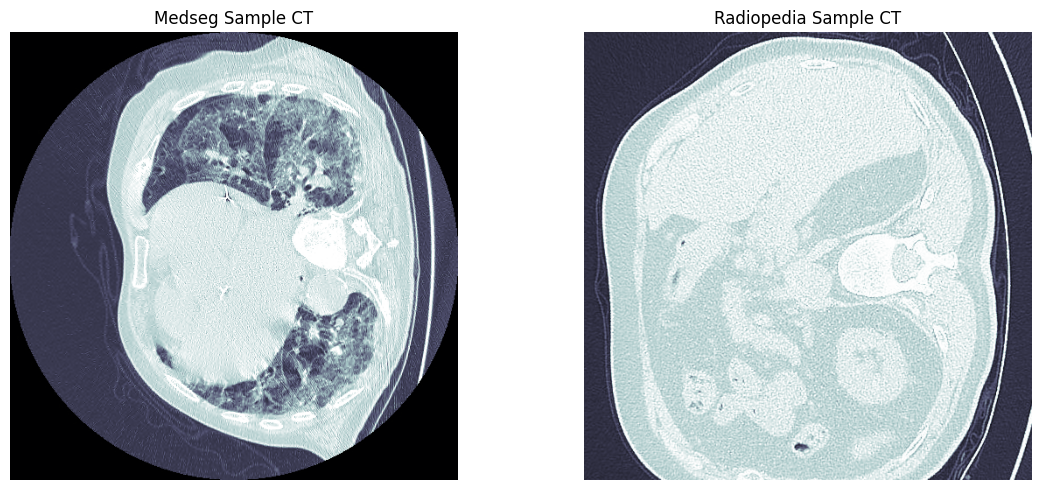


🔢 [Value Range Check]
Medseg   | Max: 597.8046699576582, Min: -1606.5217391304348
Radiopedia | Max: 291.040771484375, Min: -1414.765380859375


In [5]:
import numpy as np
import os
import matplotlib.pyplot as plt

# 1. 파일 존재 여부 확인
data_path = "data"
files = [
    "images_medseg.npy", "masks_medseg.npy", 
    "images_radiopedia.npy", "masks_radiopedia.npy", 
    "test_images_medseg.npy"
]

print("📂 [File Check]")
for f in files:
    full_path = os.path.join(data_path, f)
    exists = "✅" if os.path.exists(full_path) else "❌"
    size = f"{os.path.getsize(full_path) / (1024**2):.2f} MB" if os.path.exists(full_path) else "N/A"
    print(f"{exists} {f} | Size: {size}")

# 2. 데이터 로드 및 Shape 확인
print("\n📊 [Data Shape Check]")
try:
    img_med = np.load(os.path.join(data_path, "images_medseg.npy"))
    mask_med = np.load(os.path.join(data_path, "masks_medseg.npy"))
    print(f"Medseg   | Image: {img_med.shape} | Mask: {mask_med.shape}")
    
    img_rad = np.load(os.path.join(data_path, "images_radiopedia.npy"))
    mask_rad = np.load(os.path.join(data_path, "masks_radiopedia.npy"))
    print(f"Radiopedia | Image: {img_rad.shape} | Mask: {mask_rad.shape}")
except Exception as e:
    print(f"❌ 로드 중 에러 발생: {e}")

# 3. 실제 시각화 (이미지가 깨졌거나 까맣게 나오는지 확인)
print("\n🖼️ [Visualization Check]")
plt.figure(figsize=(12, 5))

# Medseg 샘플
plt.subplot(1, 2, 1)
plt.imshow(img_med[0].squeeze(), cmap='bone')
plt.title("Medseg Sample CT")
plt.axis('off')

# Radiopedia 샘플
plt.subplot(1, 2, 2)
plt.imshow(img_rad[0].squeeze(), cmap='bone')
plt.title("Radiopedia Sample CT")
plt.axis('off')

plt.tight_layout()
plt.show()

# 4. 값의 범위 확인 (정규화 전 상태)
print(f"\n🔢 [Value Range Check]")
print(f"Medseg   | Max: {img_med.max()}, Min: {img_med.min()}")
print(f"Radiopedia | Max: {img_rad.max()}, Min: {img_rad.min()}")